# 03 · Modelling

**Goal.** Fit and evaluate a screening model that ranks adults with *no prior diabetes
diagnosis* by their probability of a diabetes-range HbA1c (>= 6.5 %), using only
routinely available demographic and body-measurement inputs.

**Design decisions carried into this notebook**

| Decision | Rationale (established in 01 / 02) |
|---|---|
| Primary metrics = PR-AUC, recall, calibration | outcome prevalence is 2.5 % — accuracy is meaningless |
| Drop BMI, keep waist circumference | Spearman rho = 0.89 between them; waist alone matched BMI+waist in CV |
| Class weighting, not resampling | keeps the data generating process intact, plays well with calibration |
| One held-out test, scored once | 23 positives in test — repeated peeking would overfit the estimate |

The heavy lifting lives in the tested `src/` package; this notebook is the narrative
layer and the audit trail for the numbers in the report.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
pd.set_option("display.float_format", "{:.4f}".format)

from src import config
from src.data import load_analysis_frame
from src.features import make_preprocessor
from src.modeling import (
    make_logistic_pipeline, make_calibrated_model, cv_splitter,
    out_of_fold_scores, sweep_thresholds, select_threshold, evaluate, coefficient_table,
)

RANDOM_STATE = config.RANDOM_STATE

## 1 · Load the prepared cohort

In [2]:
df = load_analysis_frame()
print("cohort:", df.shape)
print(df[config.TARGET].value_counts().rename("n").to_frame().assign(
    pct=lambda t: (100 * t["n"] / t["n"].sum()).round(2)))
df.head()

cohort: (4698, 14)
                       n     pct
a1c_diabetes_range              
0                   4582 97.5300
1                    116  2.4700


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,LBXGH,WTPH2YR,SDMVSTRA,SDMVPSU,WTMEC2YR,a1c_diabetes_range
0,130378.0000,43.0000,1.0000,6.0000,5.0000,5.0000,27.0000,98.3000,5.6000,56042.1294,173.0000,2.0000,54374.4639,0
1,130379.0000,66.0000,1.0000,3.0000,5.0000,5.0000,33.5000,114.7000,5.6000,37435.7056,173.0000,2.0000,34084.7215,0
2,130386.0000,34.0000,1.0000,1.0000,4.0000,1.3300,30.2000,106.1000,5.1000,44526.2141,179.0000,1.0000,39988.4529,0
3,130387.0000,68.0000,2.0000,3.0000,5.0000,1.3200,42.6000,122.0000,5.9000,22746.2964,181.0000,1.0000,20776.2549,0
4,130388.0000,27.0000,2.0000,4.0000,4.0000,0.8100,43.7000,118.5000,4.9000,32864.2909,187.0000,1.0000,30329.5364,0


## 2 · Train / test split

Stratified 80 / 20. The test set is locked away until the very last step.

In [3]:
from sklearn.model_selection import train_test_split

# Keep all candidate numerics in X for the feature-set comparison; every model
# Pipeline selects the columns it needs via its ColumnTransformer (remainder="drop").
X = df[config.NUMERIC_CANDIDATES + config.CATEGORICAL_FEATURES].copy()
y = df[config.TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

print(f"train {X_train.shape}  positives={int(y_train.sum())}  ({y_train.mean():.2%})")
print(f"test  {X_test.shape}  positives={int(y_test.sum())}  ({y_test.mean():.2%})")

train (3758, 7)  positives=93  (2.47%)
test  (940, 7)  positives=23  (2.45%)


## 3 · Preprocessing

Numeric: median impute -> standardise. Categorical: mode impute -> one-hot (drop
first). Wrapped in a `ColumnTransformer` inside every model `Pipeline`, so the
imputation and scaling statistics are learned on training folds only — no leakage.

In [4]:
preprocessor = make_preprocessor()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tr

## 4 · Baseline 1 — DummyClassifier

The floor any real model must clear. With a 2.5 % positive rate a "always negative"
classifier scores 97.5 % accuracy and is clinically useless — PR-AUC ~ prevalence,
ROC-AUC = 0.5.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score

dummy = Pipeline([("preprocessor", make_preprocessor()),
                  ("classifier", DummyClassifier(strategy="prior"))]).fit(X_train, y_train)
d_prob = dummy.predict_proba(X_test)[:, 1]
pd.Series({
    "accuracy": accuracy_score(y_test, dummy.predict(X_test)),
    "roc_auc": roc_auc_score(y_test, d_prob),
    "pr_auc": average_precision_score(y_test, d_prob),
    "no_skill_pr_auc (=prevalence)": y_test.mean(),
}).round(4)

accuracy                        0.9755
roc_auc                         0.5000
pr_auc                          0.0245
no_skill_pr_auc (=prevalence)   0.0245
dtype: float64

## 5 · Baseline 2 — class-weighted logistic regression

First learned model: logistic regression with `class_weight="balanced"`, evaluated
with 5-fold stratified CV on the training set only.

In [6]:
from sklearn.model_selection import cross_validate

scoring = {"balanced_accuracy": "balanced_accuracy", "precision": "precision",
           "recall": "recall", "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

lr_baseline = make_logistic_pipeline(config.NUMERIC_CANDIDATES, C=1.0)   # all 4 numerics, default C
cvres = cross_validate(lr_baseline, X_train, y_train, cv=cv_splitter(), scoring=scoring, n_jobs=-1)
pd.DataFrame({m.replace("test_", ""): (v.mean(), v.std())
             for m, v in cvres.items() if m.startswith("test_")},
            index=["mean", "std"]).T.round(4)

,mean,std
balanced_accuracy,0.7306,0.0385
precision,0.0645,0.0069
recall,0.7304,0.0773
f1,0.1185,0.0127
roc_auc,0.8049,0.0353
pr_auc,0.0915,0.0239


The class-weighted linear model already separates the classes usefully: ROC-AUC
~ 0.80, PR-AUC ~ 0.09 (about 4x the no-skill rate), recall ~ 0.73. Precision is low
(~ 6 %) — expected for a rare outcome and acceptable for a *screening* stage.

## 6 · Feature-set comparison — BMI vs waist circumference

EDA found BMI and waist circumference are Spearman rho = 0.89 collinear. Test all
three options with the same model and CV.

In [7]:
feature_sets = {
    "BMI + Waist": ["RIDAGEYR", "INDFMPIR", "BMXBMI", "BMXWAIST"],
    "BMI only":    ["RIDAGEYR", "INDFMPIR", "BMXBMI"],
    "Waist only":  ["RIDAGEYR", "INDFMPIR", "BMXWAIST"],
}
rows = []
for name, cols in feature_sets.items():
    r = cross_validate(make_logistic_pipeline(cols, C=1.0), X_train, y_train,
                       cv=cv_splitter(), scoring=scoring, n_jobs=-1)
    rows.append({"feature_set": name, "pr_auc": r["test_pr_auc"].mean(),
                 "roc_auc": r["test_roc_auc"].mean(), "recall": r["test_recall"].mean()})
pd.DataFrame(rows).set_index("feature_set").round(4)

,pr_auc,roc_auc,recall
feature_set,,,
BMI + Waist,0.0915,0.8049,0.7304
BMI only,0.0819,0.7766,0.7076
Waist only,0.0960,0.8052,0.7298


**Waist-only is at least as good as BMI+waist on every metric** and avoids the
coefficient sign-flip that collinearity induces (with both in the model, BMI's
adjusted coefficient turns negative and stops being interpretable). BMI-only is
clearly worse. → **final numeric set = age, income-to-poverty ratio, waist
circumference** (`config.NUMERIC_FEATURES`).

## 7 · Model-family comparison

Logistic regression vs two tree ensembles, on the selected feature set, with
5x5 repeated stratified CV for a stable estimate.

In [8]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold

families = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000,
                                              solver="liblinear", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample",
                                            min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                                            l2_regularization=1.0, random_state=RANDOM_STATE),
}
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
rows = []
for name, clf in families.items():
    pipe = Pipeline([("preprocessor", make_preprocessor()), ("classifier", clf)])
    r = cross_validate(pipe, X_train, y_train, cv=rcv, scoring=scoring, n_jobs=-1)
    rows.append({"model": name, "pr_auc": r["test_pr_auc"].mean(), "pr_auc_std": r["test_pr_auc"].std(),
                 "roc_auc": r["test_roc_auc"].mean(), "recall": r["test_recall"].mean(),
                 "balanced_acc": r["test_balanced_accuracy"].mean()})
pd.DataFrame(rows).set_index("model").round(4)

,pr_auc,pr_auc_std,roc_auc,recall,balanced_acc
model,,,,,
Logistic Regression,0.0942,0.0293,0.7995,0.7094,0.7198
Random Forest,0.0672,0.0226,0.7469,0.0064,0.5026
Hist Gradient Boosting,0.0761,0.0315,0.7481,0.1975,0.5620


Logistic regression wins on PR-AUC, ROC-AUC and recall. Both tree ensembles collapse
toward the majority class (recall near 0, balanced accuracy near 0.5) — with 93
positives and a near-linear signal they have nothing to exploit and every incentive
to predict "negative". **The linear model is selected**, and it comes with a bonus:
directly interpretable odds ratios for a clinical audience.

## 8 · Hyper-parameter tuning (logistic regression)

Grid over regularisation strength `C` and class weight, scored on CV PR-AUC.

In [9]:
from sklearn.model_selection import GridSearchCV

grid = {
    "classifier__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 10.0],
    "classifier__class_weight": [None, "balanced", {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 40}],
}
search = GridSearchCV(
    Pipeline([("preprocessor", make_preprocessor()),
              ("classifier", LogisticRegression(max_iter=2000, solver="liblinear",
                                                random_state=RANDOM_STATE))]),
    grid, scoring="average_precision", cv=cv_splitter(), n_jobs=-1, return_train_score=True)
search.fit(X_train, y_train)
print("grid-best:", search.best_params_, " CV PR-AUC:", round(search.best_score_, 4))

top = (pd.DataFrame(search.cv_results_)
       [["param_classifier__C", "param_classifier__class_weight", "mean_test_score", "std_test_score"]]
       .sort_values("mean_test_score", ascending=False).head(8))
top.round(4)

grid-best: {'classifier__C': 2.0, 'classifier__class_weight': {0: 1, 1: 40}}  CV PR-AUC: 0.0965


,param_classifier__C,param_classifier__class_weight,mean_test_score,std_test_score
29,2.0000,"{0: 1, 1: 40}",0.0965,0.0251
14,0.1000,"{0: 1, 1: 40}",0.0963,0.0259
24,1.0000,"{0: 1, 1: 40}",0.0963,0.0249
26,2.0000,balanced,0.0963,0.0249
34,10.0000,"{0: 1, 1: 40}",0.0962,0.0248
31,10.0000,balanced,0.0961,0.0248
18,0.5000,"{0: 1, 1: 20}",0.0960,0.0268
16,0.5000,balanced,0.0960,0.0251


The tuning surface is **flat**: the top configurations sit within ~0.001 PR-AUC of
each other, far inside the CV standard error (~0.025). Hyper-parameters are not the
lever here. Following a one-standard-error / parsimony rule we take the **most
regularised model with the standard balanced class weight**: `C = 0.1`,
`class_weight = "balanced"` (`config.LOGREG_PARAMS`).

## 9 · Probability calibration

Class weighting distorts the predicted probabilities (they no longer match observed
frequencies). We wrap the tuned pipeline in `CalibratedClassifierCV` (Platt / sigmoid,
5-fold) and check the calibration on leakage-free out-of-fold predictions.

OOF ROC-AUC 0.8049   OOF PR-AUC 0.0742   OOF Brier 0.02360


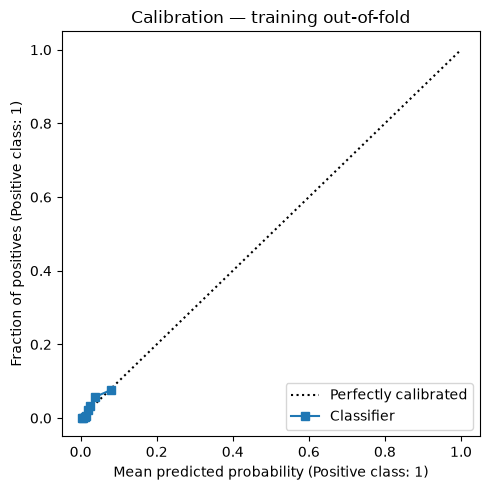

In [10]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay

calibrated = make_calibrated_model()
oof_scores = out_of_fold_scores(calibrated, X_train, y_train)

print(f"OOF ROC-AUC {roc_auc_score(y_train, oof_scores):.4f}   "
      f"OOF PR-AUC {average_precision_score(y_train, oof_scores):.4f}   "
      f"OOF Brier {brier_score_loss(y_train, oof_scores):.5f}")

fig, ax = plt.subplots(figsize=(5, 5))
CalibrationDisplay.from_predictions(y_train, oof_scores, n_bins=8, strategy="quantile", ax=ax)
ax.set_title("Calibration — training out-of-fold")
plt.tight_layout(); plt.show()

## 10 · Threshold selection for screening

A screening tool should catch most true cases. We choose the operating threshold on
**training out-of-fold scores** (never the test set): the highest score cut-point
that still reaches the target recall.

In [11]:
operating = sweep_thresholds(y_train, oof_scores,
                             [*config.ALT_RECALL_TARGETS, config.RECALL_TARGET]
                             ).sort_values("recall_target").reset_index(drop=True)
operating.round(4)

,recall_target,threshold,flagged_rate,precision,recall,specificity,balanced_accuracy,tp,fp,fn,tn
0,0.7000,0.0293,0.2634,0.0667,0.7097,0.7479,0.7288,66,924,27,2741
1,0.8000,0.0235,0.3502,0.0570,0.8065,0.6614,0.7339,75,1241,18,2424
2,0.9000,0.0207,0.3994,0.0560,0.9032,0.6134,0.7583,84,1417,9,2248


In [12]:
threshold = select_threshold(y_train, oof_scores, config.RECALL_TARGET)
print(f"selected operating threshold (>= {config.RECALL_TARGET:.0%} OOF recall): {threshold:.4f}")

selected operating threshold (>= 80% OOF recall): 0.0235


At the 80 % target the model flags ~35 % of the cohort. The 70 % and 90 % rows are
kept as alternative operating points — the threshold is a business dial, not a
property of the model, and calibrated scores mean it can be re-set without retraining.

## 11 · Fit the final model and score the held-out test **once**

In [13]:
final_model = make_calibrated_model()
final_model.fit(X_train, y_train)

result = evaluate(final_model, X_test, y_test, threshold)
pd.Series(result.metrics).round(4)

threshold             0.0235
flagged_rate          0.3255
precision             0.0719
recall                0.9565
specificity           0.6903
balanced_accuracy     0.8234
tp                   22.0000
fp                  284.0000
fn                    1.0000
tn                  633.0000
accuracy              0.6968
f1                    0.1337
roc_auc               0.8439
pr_auc                0.0740
brier_score           0.0236
no_skill_pr_auc       0.0245
dtype: float64

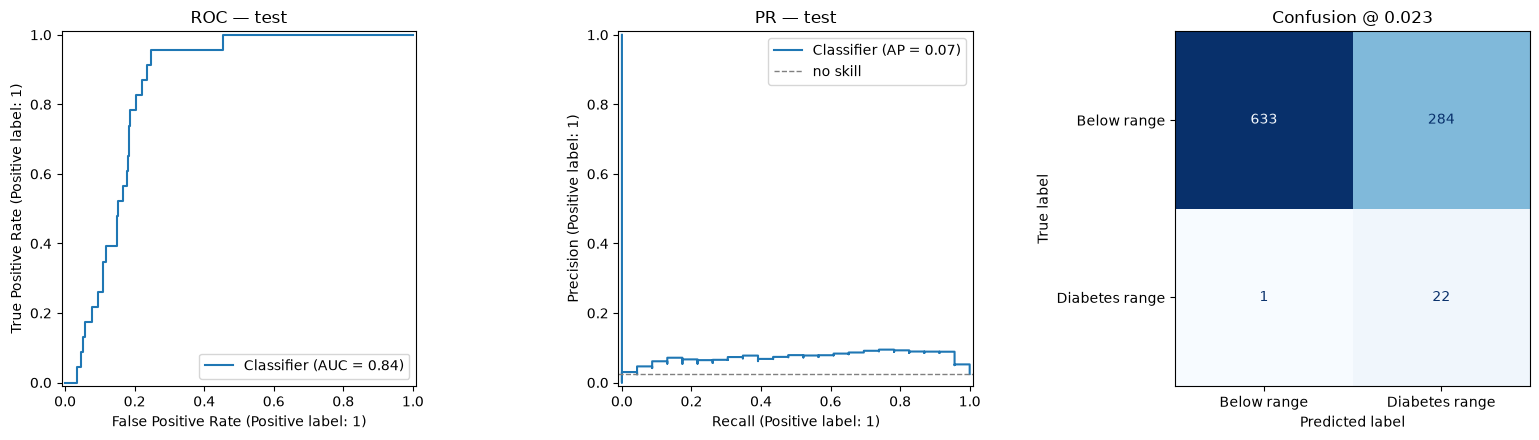

In [14]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
RocCurveDisplay.from_predictions(y_test, result.scores, ax=axes[0]); axes[0].set_title("ROC — test")
PrecisionRecallDisplay.from_predictions(y_test, result.scores, ax=axes[1]); axes[1].set_title("PR — test")
axes[1].axhline(y_test.mean(), ls="--", c="grey", lw=1, label="no skill"); axes[1].legend()
ConfusionMatrixDisplay(result.confusion,
    display_labels=["Below range", "Diabetes range"]).plot(cmap="Blues", colorbar=False, ax=axes[2])
axes[2].set_title(f"Confusion @ {threshold:.3f}")
plt.tight_layout(); plt.show()

**Held-out test (940 adults, 23 positives)** — at the 80 %-recall operating point the
calibrated model actually recovers **22 of 23** diabetes-range participants
(recall 96 %), at 69 % specificity and 7 % precision. ROC-AUC 0.84, PR-AUC 0.074
(~3x the 0.024 no-skill rate), Brier 0.024 (well calibrated).

Read it as a *triage filter*: screening ~1 in 3 adults with a confirmatory HbA1c
would find almost every undiagnosed case in this sample, at the cost of ~284
false positives per 22 true positives. With only 23 test positives the recall point
estimate is wide — this is a proof of concept, not a validated device.

## 12 · What the model learned — odds ratios

In [15]:
logit = make_logistic_pipeline().fit(X_train, y_train)
coefs = coefficient_table(logit)
coefs.round(3)

,feature,coefficient,odds_ratio
0,BMXWAIST,1.0540,2.8680
1,RIDAGEYR,0.7560,2.1300
2,DMDEDUC2_2.0,0.6870,1.9890
3,RIDRETH3_4.0,0.6630,1.9400
4,RIDRETH3_6.0,0.1880,1.2070
5,RIAGENDR_2.0,0.0020,1.0020
6,DMDEDUC2_3.0,-0.1960,0.8220
7,INDFMPIR,-0.2300,0.7940
8,DMDEDUC2_5.0,-0.3040,0.7380
9,DMDEDUC2_4.0,-0.3670,0.6930


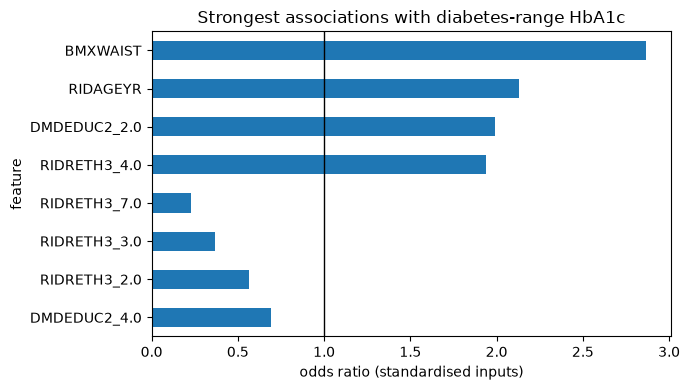

In [16]:
top = coefs.reindex(coefs["odds_ratio"].sub(1).abs().sort_values(ascending=False).index).head(8)
ax = top.set_index("feature")["odds_ratio"].iloc[::-1].plot.barh(figsize=(7, 4))
ax.axvline(1.0, c="k", lw=1); ax.set_xlabel("odds ratio (standardised inputs)")
ax.set_title("Strongest associations with diabetes-range HbA1c")
plt.tight_layout(); plt.show()

Direction is clinically sensible: **larger waist circumference** and **older age**
are the dominant risk signals; lower income-to-poverty ratio, less education, and
Non-Hispanic Black race/ethnicity carry higher odds — consistent with the
descriptive gradients in notebook 02 and the epidemiological literature. These are
associations in an observational sample, not causal effects.

## 13 · Persist the model and metrics

In [17]:
from src.pipeline import run as run_pipeline
summary = run_pipeline(save=True)     # writes models/*.joblib, reports/model_metrics.json, reports/figures/*
print("saved:", config.MODEL_PATH.name, "| threshold", round(summary["selected_threshold"], 4))
pd.Series(summary["test_metrics"]).round(4)

model  -> models/undiagnosed_diabetes_screener.joblib
metrics-> reports/model_metrics.json
saved: undiagnosed_diabetes_screener.joblib | threshold 0.0235


threshold             0.0235
flagged_rate          0.3255
precision             0.0719
recall                0.9565
specificity           0.6903
balanced_accuracy     0.8234
tp                   22.0000
fp                  284.0000
fn                    1.0000
tn                  633.0000
accuracy              0.6968
f1                    0.1337
roc_auc               0.8439
pr_auc                0.0740
brier_score           0.0236
no_skill_pr_auc       0.0245
dtype: float64

## 14 · Summary, limitations, next steps

**Result.** A calibrated, class-weighted logistic regression on six routinely
available inputs (age, income-to-poverty ratio, waist circumference, sex,
race/ethnicity, education) ranks undiagnosed diabetes-range HbA1c with ROC-AUC 0.84
and PR-AUC ~3x no-skill. At an 80 %-recall screening threshold it caught 22/23
held-out cases while flagging ~1/3 of adults for a confirmatory test.

**Limitations**
- Outcome is HbA1c >= 6.5 % only; CDC's undiagnosed-diabetes definition also uses
  fasting glucose, so this under-counts true cases (weighted prevalence 2.0 % vs
  CDC 4.5 %).
- 116 positives total, 23 in test — all minority-class metrics have wide intervals.
- Cross-sectional NHANES; associations are not causal and the model is not calibrated
  to any clinical population.
- Survey design (strata / PSU / weights) is used for the prevalence sanity check but
  not folded into the model's standard errors.

**Next steps**
- Add the already-downloaded blood-pressure, smoking and physical-activity modules
  (BPXO / BPQ / SMQ / PAQ) as a v2 feature block.
- External validation on the 2017-2020 NHANES cycle.
- Decision-curve analysis to put the operating threshold on a cost basis.
- Survey-weighted logistic regression (`statsmodels`) for design-correct inference.